<a href="https://colab.research.google.com/github/Nurdaylight/An-Econ-771/blob/main/PS3/Ps3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:

#
from scipy.stats import norm
import numpy as np
import torch
import matplotlib.pyplot as plt
import math

In [2]:
# This is for the timing of the code run time, please do not modify
import time
start_time = time.time()

# I

# Part **a**

In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
#Params

M = 5000
n = 20
beta_true = torch.tensor([1.0, 2.0, 3.0], device=device)  # (β1, β2, β3)

#>--------------------------------------------------------

# Generate tensor of all data with dimensions M*N*K
X = torch.randn(M, n, 3, device=device)

#Notice in last dimension first vector is residuals times1
#  and constant is added after

Y= X@beta_true +1.0

#store errors, replace constant into regression data
errors = X[:, :, 0]
X[:, :, 0] = 1.0

# Compute estimates
XtX = X.transpose(1, 2) @ X      # shape: (M, 3, 3)
XtX_inv = torch.linalg.inv(XtX)  # shape: (M, 3, 3)

beta_hat= XtX_inv @ X.transpose(1, 2)@Y.view(M, n, 1)


**Answer**: all estimates are stored in  ```beta_hat```  which is too large to print [ (M*3) matrix ]



> ---------------------------------------------------------------




#  Part **b**

In [4]:
#Use the fact that sigma is known and = 1

# ---- extract diagonal using torch ONLY ----
XtX_inv_diag = torch.diagonal(XtX_inv, dim1=1, dim2=2)   # (M, 3)

# ---- standard errors ----
se = torch.sqrt(1 * XtX_inv_diag)
diff=(beta_hat - beta_true.view(1,-1,1)).view(M,3)                     # (M, 3)
z= diff/se   # (M, 3)



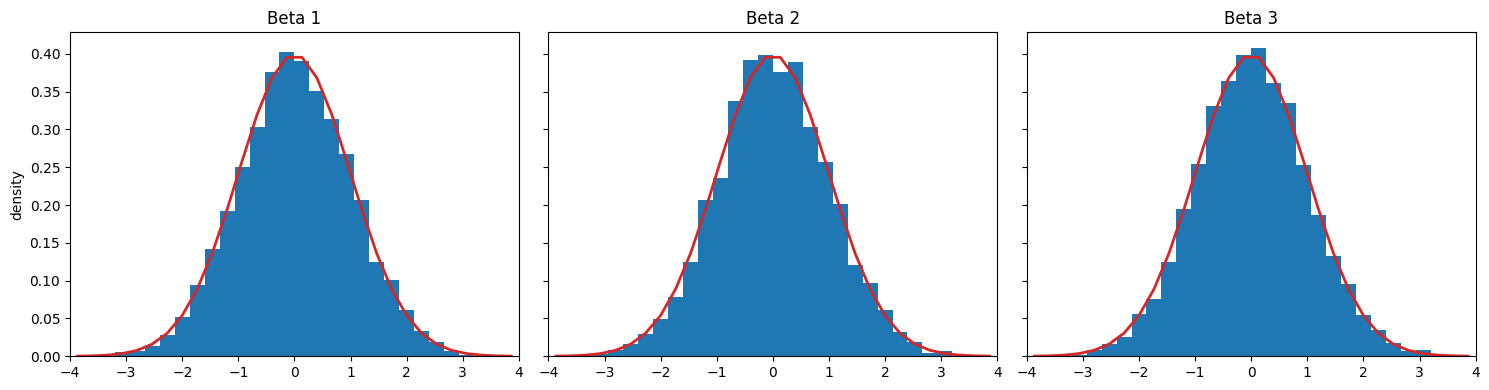

In [5]:

z_cpu = z.cpu()
edges = torch.linspace(-4, 4, 31)   # 40 bins => 41 edges
widths = (edges[1:] - edges[:-1])

centers = 0.5 * (edges[1:] + edges[:-1])

# standard normal pdf at centers (no linspace needed beyond edges)
phi = (1 / math.sqrt(2 * math.pi)) * torch.exp(-0.5 * centers**2)

fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)

for k, ax in enumerate(axes):
    counts = torch.histc(z_cpu[:, k], bins=30, min=-4.0, max=4.0)  # counts per bin
    density = counts / (counts.sum() * widths)                     # convert to density

    ax.bar(centers, density, width=widths, align="center")
    ax.plot(centers, phi,color="tab:red", linewidth=2)
    ax.set_title(f"Beta {k+1}")
    ax.set_xlim(-4, 4)

axes[0].set_ylabel("density")
plt.tight_layout()
plt.show()

# Part **c**


In [6]:
#F
error_hat= Y.view(M,n,1) - (X@beta_hat)
var=error_hat.transpose(1,2)@error_hat /(n-3)
se_hat=torch.sqrt(var.squeeze(-1)   * XtX_inv_diag)
t=diff /se_hat

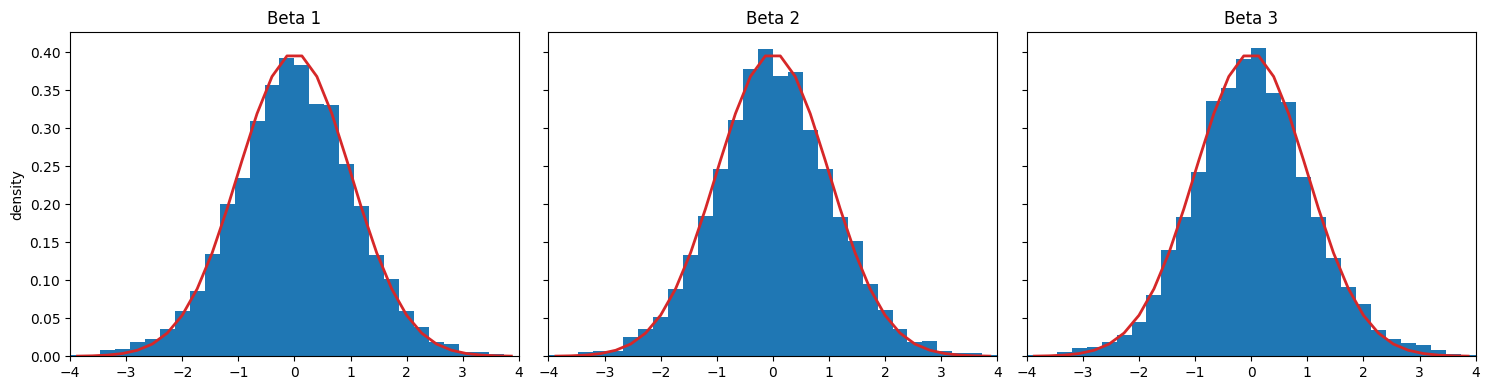

In [7]:
t_cpu = t.cpu()



fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)

for k, ax in enumerate(axes):
    counts = torch.histc(t_cpu[:, k], bins=30, min=-4.0, max=4.0)  # counts per bin
    density = counts / (counts.sum() * widths)                     # convert to density

    ax.bar(centers, density, width=widths, align="center")
    ax.plot(centers, phi,color="tab:red", linewidth=2)
    ax.set_title(f"Beta {k+1}")
    ax.set_xlim(-4, 4)

axes[0].set_ylabel("density")
plt.tight_layout()
plt.show()

**Answer:** this estimator is distributed according to T distribution with n-k (17) degrees of freedom.

> ---------------------------------------------------------------

# Part **d**

In [25]:
crit=  2.110 #Analytical threshold (GOOGLED)
false_pos = (torch.sum((t > crit) | (t < -crit), dim=0))/M
print(f"rate of false positives is {false_pos.tolist()}")

rate of false positives is [0.052400000393390656, 0.04959999769926071, 0.05139999836683273]


rate of false positives is tensor([0.0524, 0.0496, 0.0514], device='cuda:0')


In [8]:
# This is for the timing of the code run time, please do not modify
end_time = time.time()

In [9]:
end_time-start_time

2.900879144668579